# Crop Recommendation - Logistic Regression Model
**Role:** Jaddu Gowthami — Problem Definition, Workflow Design, Logistic Regression Model, Crop Prediction

This notebook picks up after the team's preprocessing steps (null check -> no missing values, outliers capped using IQR method) and builds the Logistic Regression model for predicting the best crop.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('fivethirtyeight')
%matplotlib inline

## 1. Load Dataset

In [2]:
data = pd.read_csv("Crop_recommendation.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
data.shape

(2200, 8)

## 2. Outlier Capping (consistent with team's outlier_handling notebook)
Re-applying the same IQR capping here so this notebook is self-contained and reproducible on its own.

In [4]:
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

for col in columns:
    data = cap_outliers(data, col)

print("Outliers capped successfully!")

Outliers capped successfully!


## 3. Encode Target Label
`label` is the crop name (22 classes) - encode it to numeric form for the model, but keep the encoder so we can decode predictions back to crop names.

In [5]:
le = LabelEncoder()
data['label_encoded'] = le.fit_transform(data['label'])

print("Number of crop classes:", len(le.classes_))
print("Classes:", list(le.classes_))

Number of crop classes: 22
Classes: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## 4. Feature / Target Split

In [6]:
X = data[columns]
y = data['label_encoded']

X.shape, y.shape

((2200, 7), (2200,))

## 5. Train-Test Split (80-20, stratified to keep crop class balance)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1760, 7)
Test shape: (440, 7)


## 6. Feature Scaling
Logistic Regression is sensitive to feature scale (N/P/K are 0-200 range while ph is 0-14), so we standardize the features.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Build & Train Logistic Regression Model

In [9]:
log_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


## 8. Evaluate the Model

In [10]:
y_pred = log_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 97.95%


In [11]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

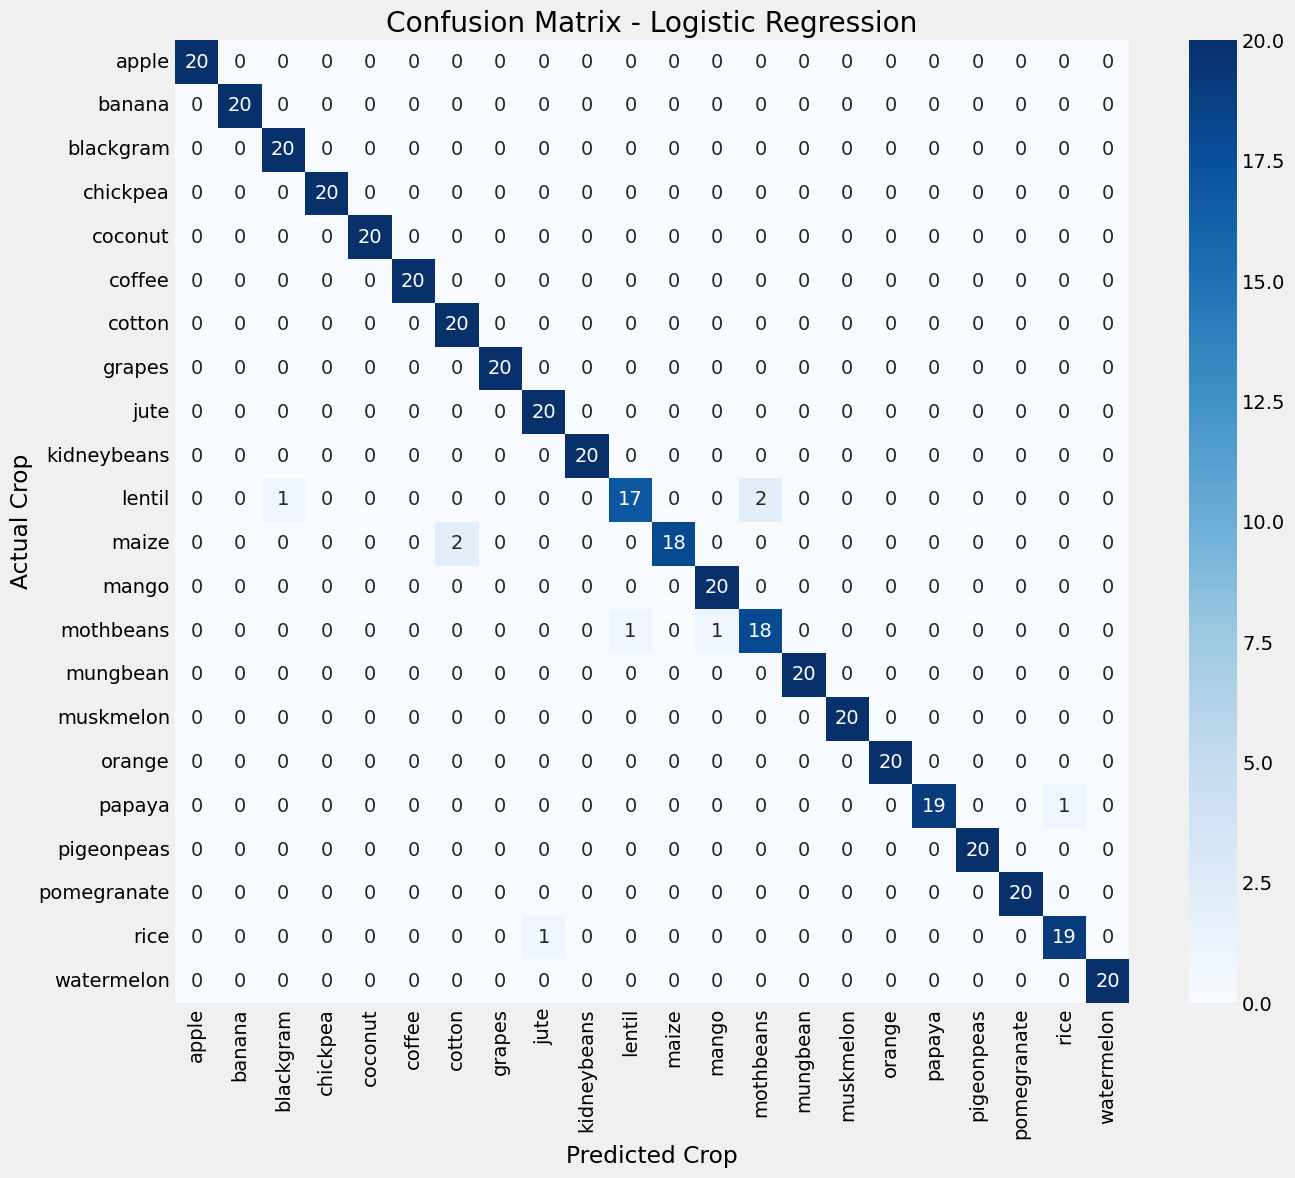

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Cross-Validation (sanity check that accuracy isn't a fluke of one split)

In [13]:
from sklearn.model_selection import cross_val_score

X_scaled_full = scaler.fit_transform(X)
cv_scores = cross_val_score(log_model, X_scaled_full, y, cv=5)

print("Cross-validation scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%  (+/- {cv_scores.std()*100:.2f}%)"
)

Cross-validation scores: [0.97045455 0.95909091 0.98181818 0.97727273 0.98181818]
Mean CV Accuracy: 97.41%  (+/- 0.86%)


## 10. Crop Prediction Function
Implements the actual prediction task: given soil & climate parameters, recommend the best crop.

In [14]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    """Predict the best crop given soil nutrient and climate parameters."""
    input_df = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]], columns=columns)
    input_scaled = scaler.transform(input_df)

    pred_encoded = log_model.predict(input_scaled)[0]
    pred_crop = le.inverse_transform([pred_encoded])[0]

    # Top-3 most probable crops, for extra context
    probs = log_model.predict_proba(input_scaled)[0]
    top3_idx = np.argsort(probs)[-3:][::-1]
    top3 = [(le.inverse_transform([i])[0], round(probs[i]*100, 2)) for i in top3_idx]

    return pred_crop, top3

In [15]:
# Example usage
result, top3 = predict_crop(N=90, P=42, K=43, temperature=20.8, humidity=82, ph=6.5, rainfall=202.9)

print("Recommended Crop:", result)
print("Top 3 probable crops:", top3)

Recommended Crop: rice
Top 3 probable crops: [('rice', np.float64(83.15)), ('jute', np.float64(15.85)), ('coffee', np.float64(0.54))]


## 11. Feature Importance (Logistic Regression coefficients)
Average absolute coefficient magnitude across all classes - gives a rough sense of which features drive the predictions most.

/tmp/ipykernel_598/420090679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


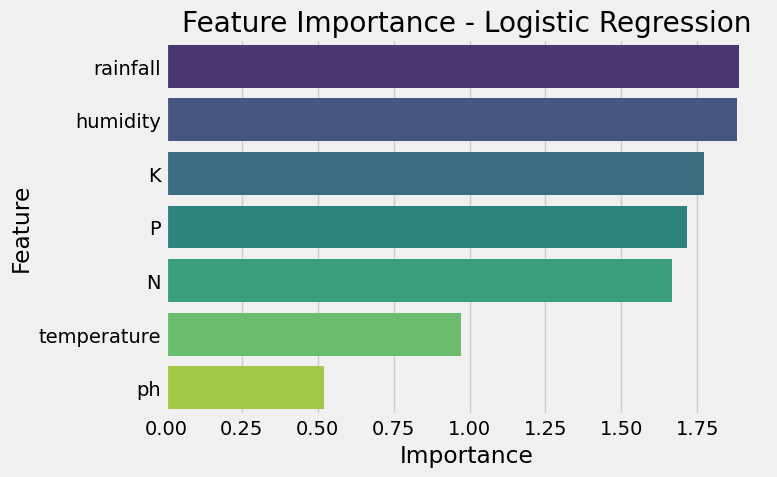

,Feature,Importance
6,rainfall,1.888425
4,humidity,1.879508
2,K,1.772051
1,P,1.717605
0,N,1.667921
3,temperature,0.971982
5,ph,0.521187


In [16]:
coef_importance = np.mean(np.abs(log_model.coef_), axis=0)
importance_df = pd.DataFrame({'Feature': columns, 'Importance': coef_importance}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Logistic Regression')
plt.tight_layout()
plt.show()

importance_df